# **Preprocesamiento y Análisis Exploratorio de los Datos**

##  1\.1 Base de datos

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nilkamalsaha/crm-sales-opportunities-on-google-sheets")

print("Path to dataset files:", path)

100%|██████████| 143k/143k [00:00<00:00, 26.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nilkamalsaha/crm-sales-opportunities-on-google-sheets/versions/1


In [2]:
import os

for file in os.listdir(path):
    print(file)

sales_teams.csv
accounts.csv
data_dictionary.csv
products.csv
sales_pipeline.csv


In [3]:
import pandas as pd

sales_pipeline = pd.read_csv(f"{path}/sales_pipeline.csv")
accounts = pd.read_csv(f"{path}/accounts.csv")
sales_teams = pd.read_csv(f"{path}/sales_teams.csv")
products = pd.read_csv(f"{path}/products.csv")

In [4]:
print("SALES PIPELINE")
display(sales_pipeline.head())

print("ACCOUNTS")
display(accounts.head())

print("SALES TEAMS")
display(sales_teams.head())

print("PRODUCTS")
display(products.head())

SALES PIPELINE


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0


ACCOUNTS


,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,NaN
1,Betasoloin,medical,1999,251.41,495,United States,NaN
2,Betatech,medical,1986,647.18,1185,Kenya,NaN
3,Bioholding,medical,2012,587.34,1356,Philipines,NaN
4,Bioplex,medical,1991,326.82,1016,United States,NaN


SALES TEAMS


,sales_agent,manager,regional_office
0,Anna Snelling,Dustin Brinkmann,Central
1,Cecily Lampkin,Dustin Brinkmann,Central
2,Versie Hillebrand,Dustin Brinkmann,Central
3,Lajuana Vencill,Dustin Brinkmann,Central
4,Moses Frase,Dustin Brinkmann,Central


PRODUCTS


,product,series,sales_price
0,GTX Basic,GTX,550
1,GTX Pro,GTX,4821
2,MG Special,MG,55
3,MG Advanced,MG,3393
4,GTX Plus Pro,GTX,5482


In [5]:
datasets = {
    "sales_pipeline": sales_pipeline,
    "accounts": accounts,
    "sales_teams": sales_teams,
    "products": products
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

sales_pipeline: (8800, 8)
accounts: (85, 7)
sales_teams: (35, 3)
products: (7, 3)


In [16]:
import pandas as pd

# Cargar datasets
sales_pipeline = pd.read_csv(f"{path}/sales_pipeline.csv")
accounts = pd.read_csv(f"{path}/accounts.csv")
sales_teams = pd.read_csv(f"{path}/sales_teams.csv")
products = pd.read_csv(f"{path}/products.csv")

# Join con accounts
df = sales_pipeline.merge(
    accounts,
    on="account",
    how="left"
)

# Join con sales teams
df = df.merge(
    sales_teams,
    on="sales_agent",
    how="left"
)

# Join con products
df = df.merge(
    products,
    on="product",
    how="left"
)

# Ver resultado
df.head()

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,sector,year_established,revenue,employees,office_location,subsidiary_of,manager,regional_office,series,sales_price
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,retail,2001.0,718.62,2448.0,United States,NaN,Dustin Brinkmann,Central,GTX,1096.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,medical,2002.0,3178.24,4540.0,United States,NaN,Melvin Marxen,Central,NaN,NaN
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,retail,2001.0,718.62,2448.0,United States,NaN,Melvin Marxen,Central,MG,55.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,software,1998.0,2714.90,2641.0,United States,Acme Corporation,Dustin Brinkmann,Central,GTX,550.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,services,1982.0,792.46,1299.0,United States,NaN,Summer Sewald,West,GTX,550.0


## 1\.2 Preprocesamiento de los datos

Durante la etapa de preprocesamiento se realizó una exploración inicial y validación de la calidad de los datos provenientes del dataset CRM de oportunidades comerciales. Primero, se cargaron e integraron las tablas `sales_pipeline`, `accounts`, `sales_teams` y `products` mediante llaves relacionales correspondientes, construyendo un dataset consolidado para el análisis.

Posteriormente, se llevó a cabo una revisión de registros nulos identificando variables con información faltante, especialmente en columnas como `account`, `close_date` y `close_value`. Se detectó que muchos registros sin cuenta asociada pertenecían a oportunidades en etapas tempranas del pipeline comercial (`Engaging` y `Prospecting`), por lo que estos valores fueron reemplazados por `"TBD"` (*To Be Defined*), interpretándose como cuentas aún no definidas dentro del proceso de ventas. Asimismo, las columnas `close_date` y `close_value` se mantuvieron vacías para estos casos, ya que representan oportunidades todavía no cerradas.

También se realizó la validación de tipos de datos de cada variable, identificando columnas numéricas, categóricas y de fecha. Las variables temporales como `engage_date` y `close_date` fueron convertidas correctamente al formato `datetime` para facilitar futuros análisis temporales y cálculos relacionados con ciclos de venta.

Adicionalmente, se verificó la existencia de registros duplicados y se evaluó la estructura general del dataset, revisión de valores únicos y la integridad de los datos. Estas actividades permitieron asegurar una base de datos más limpia, consistente y adecuada para el análisis exploratorio y el desarrollo posterior del proyecto analítico.


### Registros Nulos

In [17]:
df.shape

(8800, 18)

In [18]:
df.columns

Index(['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage',
       'engage_date', 'close_date', 'close_value', 'sector',
       'year_established', 'revenue', 'employees', 'office_location',
       'subsidiary_of', 'manager', 'regional_office', 'series', 'sales_price'],
      dtype='object')

In [19]:
df.isnull().sum()

,0
opportunity_id,0
sales_agent,0
product,0
account,1425
deal_stage,0
engage_date,500
close_date,2089
close_value,2089
sector,1425
year_established,1425


In [21]:
# =========================================
# VER VALORES NULOS
# =========================================

datasets = {
    "sales_pipeline": sales_pipeline,
    "accounts": accounts,
    "sales_teams": sales_teams,
    "products": products
}

for name, df in datasets.items():

    print("\n" + "="*60)
    print(f"DATASET: {name}")
    print("="*60)

    # cantidad de nulos
    nulls = df.isnull().sum()

    # solo columnas con nulos
    nulls = nulls[nulls > 0]

    if len(nulls) > 0:
        print("\nColumnas con valores nulos:")
        display(nulls.sort_values(ascending=False))
    else:
        print("\nNo hay valores nulos")


DATASET: sales_pipeline

Columnas con valores nulos:


,0
close_value,2089
close_date,2089
account,1425
engage_date,500



DATASET: accounts

Columnas con valores nulos:


,0
subsidiary_of,70



DATASET: sales_teams

No hay valores nulos

DATASET: products

No hay valores nulos


In [22]:
# =========================================
# REGISTROS DONDE ACCOUNT ES NULO
# =========================================

account_nulls = sales_pipeline[
    sales_pipeline["account"].isnull()
]

print("Cantidad de registros con account nulo:")
print(account_nulls.shape[0])

display(account_nulls)

Cantidad de registros con account nulo:
1425


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
9,HAXMC4IX,James Ascencio,MG Advanced,NaN,Engaging,2016-11-03,NaN,NaN
42,EG7OFLFR,Kami Bicknell,GTX Basic,NaN,Engaging,2016-11-14,NaN,NaN
44,OLVI7L8M,Cassey Cress,GTXPro,NaN,Engaging,2016-11-16,NaN,NaN
56,F5U1ACDD,Kami Bicknell,GTX Plus Basic,NaN,Engaging,2016-11-19,NaN,NaN
60,ZZY4516R,Hayden Neloms,MG Advanced,NaN,Engaging,2016-11-20,NaN,NaN
...,...,...,...,...,...,...,...,...
8795,9MIWFW5J,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN
8796,6SLKZ8FI,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN
8797,LIB4KUZJ,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN
8798,18IUIUK0,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN


In [26]:
# =========================================
# CAMBIAR NAMING POR TBD (TO BE DEFINED) SON CUENTAS QUE ESTAN ENGAGING O PROSPECTING EN DEAL_STAGE //ES POSIBLE QUE EXISTAN DATOS NULOS EN LAS FECHAS
# DEBIDO A AL TIPO DE ETAPA EN LA QUE SE ENCUENTRAN, SOLO ETAPA = WON OR LOST TIENEN LOS CAMPOS FECHAS COMPLETOS YA QUE EL PIPELINE ESTA DESARROLLADO AL 100%
# =========================================

# =========================================
# CAMBIAR ACCOUNT NULO POR "TBD"
# SOLO SI deal_stage ES:
# - Engaging
# - Prospecting
# =========================================

sales_pipeline.loc[
    (
        sales_pipeline["account"].isnull()
    ) &
    (
        sales_pipeline["deal_stage"].isin(
            ["Engaging", "Prospecting"]
        )
    ),
    "account"
] = "TBD"

# verificar
display(
    sales_pipeline[
        sales_pipeline["account"] == "TBD"
    ].head()
)

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
9,HAXMC4IX,James Ascencio,MG Advanced,TBD,Engaging,2016-11-03,NaN,NaN
42,EG7OFLFR,Kami Bicknell,GTX Basic,TBD,Engaging,2016-11-14,NaN,NaN
44,OLVI7L8M,Cassey Cress,GTXPro,TBD,Engaging,2016-11-16,NaN,NaN
56,F5U1ACDD,Kami Bicknell,GTX Plus Basic,TBD,Engaging,2016-11-19,NaN,NaN
60,ZZY4516R,Hayden Neloms,MG Advanced,TBD,Engaging,2016-11-20,NaN,NaN


### Tipos de datos de las variables

In [31]:
# =========================================
# VER TIPO DE DATO DE CADA COLUMNA
# =========================================

df.dtypes

,0
opportunity_id,object
sales_agent,object
product,object
account,object
deal_stage,object
engage_date,object
close_date,object
close_value,float64
sector,object
year_established,float64


In [32]:
# =========================================
# CONVERTIR COLUMNAS engage_date // close_date A FORMATO FECHA
# =========================================

date_columns = [
    "engage_date",
    "close_date"
]

for col in date_columns:

    df[col] = pd.to_datetime(
        df[col],
        errors="coerce"
    )

# verificar tipos
print(df[date_columns].dtypes)

engage_date    datetime64[ns]
close_date     datetime64[ns]
dtype: object


### Valores duplicados

In [34]:
df.duplicated().sum()

np.int64(0)

### Ing de Caracteristicas

In [74]:
# =========================================
# CREAR VARIABLE BINARIA:
# OPORTUNIDAD GANADA O NO
# =========================================

df["is_won"] = np.where(
    df["deal_stage"] == "Won",
    1,
    0
)

# verificar
display(
    df[
        [
            "deal_stage",
            "is_won"
        ]
    ].head()
)

,deal_stage,is_won
0,Won,1
1,Won,1
2,Won,1
3,Won,1
4,Won,1


In [48]:
# =========================================
# CREAR COLUMNA:
# DURACIÓN DEL CICLO DE VENTA
# =========================================

df["sales_cycle_days"] = (
    df["close_date"] - df["engage_date"]
).dt.days

# verificar
display(
    df[
        [
            "engage_date",
            "close_date",
            "sales_cycle_days"
        ]
    ].head()
)

,engage_date,close_date,sales_cycle_days
0,2016-10-20,2017-03-01,132.0
1,2016-10-25,2017-03-11,137.0
2,2016-10-25,2017-03-07,133.0
3,2016-10-25,2017-03-09,135.0
4,2016-10-25,2017-03-02,128.0


## 1\.3 Análisis Exploratorio de los datos

A nivel exploratorio, se analizaron las variables cualitativas identificando categorías únicas y frecuencias por etapa del pipeline comercial. Se encontró una distribución importante de oportunidades entre estados como Won, Lost, Prospecting y Engaging, permitiendo comprender mejor el comportamiento general del funnel de ventas.

Asimismo, se desarrollaron múltiples análisis de negocio y visualizaciones. Entre los principales hallazgos se destacan:

*  Identificación de los productos con mayores valores de cierre acumulados.
* Identificación de los comerciales con mejor desempeño en valor de cierre y participación porcentual sobre el total del valor de cierr.
* Análisis de las cuentas con mayor revenue y mayor cantidad de empleados, permitiendo reconocer clientes estratégicos de gran tamaño.
* Evaluación de la evolución mensual de oportunidades Engaging, así como de oportunidades ganadas (Won) y perdidas (Lost).
* Construcción de indicadores de conversión comercial mediante el cálculo del Conversion Rate mensual, permitiendo medir la eficiencia del pipeline de ventas a lo largo del tiempo.
* Análisis del ciclo promedio de ventas, determinando valores máximos, mínimos y promedio general de duración del proceso comercial por cuenta.

En general, el análisis exploratorio permitió comprender la estructura, calidad y comportamiento del dataset, además de generar insights relevantes sobre el desempeño comercial, la conversión de oportunidades, el comportamiento de clientes y la dinámica del proceso de ventas.

In [36]:
# =========================================
# VER VALORES UNICOS DE VARIABLES CUALITATIVAS
# =========================================

# seleccionar columnas tipo object/category
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns

for col in categorical_cols:

    print("\n" + "="*60)
    print(f"COLUMNA: {col}")
    print("="*60)

    print(f"\nCantidad de valores únicos: {df[col].nunique()}")

    print("\nValores únicos:")
    print(df[col].unique())


COLUMNA: opportunity_id

Cantidad de valores únicos: 8800

Valores únicos:
['1C1I7A6R' 'Z063OYW0' 'EC4QE1BX' ... 'LIB4KUZJ' '18IUIUK0' '8I5ONXJX']

COLUMNA: sales_agent

Cantidad de valores únicos: 30

Valores únicos:
['Moses Frase' 'Darcel Schlecht' 'Zane Levy' 'Anna Snelling'
 'Vicki Laflamme' 'Markita Hansen' 'Niesha Huffines' 'James Ascencio'
 'Gladys Colclough' 'Maureen Marcano' 'Hayden Neloms' 'Rosalina Dieter'
 'Versie Hillebrand' 'Daniell Hammack' 'Elease Gluck' 'Violet Mclelland'
 'Kami Bicknell' 'Rosie Papadopoulos' 'Kary Hendrixson' 'Reed Clapper'
 'Wilburn Farren' 'Garret Kinder' 'Marty Freudenburg' 'Cassey Cress'
 'Lajuana Vencill' 'Boris Faz' 'Donn Cantrell' 'Corliss Cosme'
 'Cecily Lampkin' 'Jonathan Berthelot']

COLUMNA: product

Cantidad de valores únicos: 7

Valores únicos:
['GTX Plus Basic' 'GTXPro' 'MG Special' 'GTX Basic' 'MG Advanced'
 'GTX Plus Pro' 'GTK 500']

COLUMNA: account

Cantidad de valores únicos: 85

Valores únicos:
['Cancity' 'Isdom' 'Codehow' 'Hatfan

In [44]:
# =========================================
# TOP 5 PRODUCTOS + %
# SOLO DEAL_STAGE = "Won"
# =========================================

top_products = (
    df[
        df["deal_stage"] == "Won"
    ]
    .groupby("product")["close_value"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

# total general de ventas ganadas
total_sales = (
    df[
        df["deal_stage"] == "Won"
    ]["close_value"].sum()
)

# calcular porcentaje
top_products["%_del_total"] = (
    top_products["close_value"] / total_sales * 100
).round(2)

display(top_products)

,product,close_value,%_del_total
0,GTXPro,3510578.0,35.09
1,GTX Plus Pro,2629651.0,26.28
2,MG Advanced,2216387.0,22.15
3,GTX Plus Basic,705275.0,7.05
4,GTX Basic,499263.0,4.99


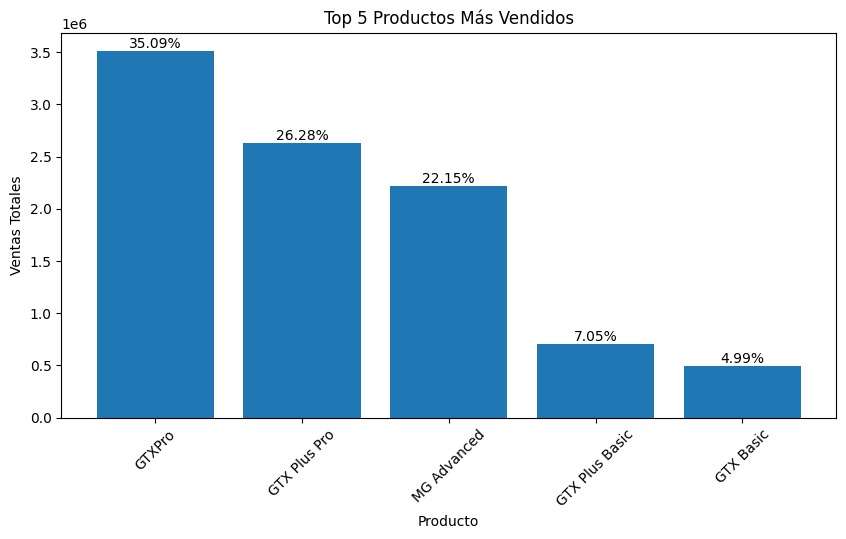

In [45]:
# =========================================
# GRAFICO TOP 5 PRODUCTOS + %
# =========================================

plt.figure(figsize=(10,5))

bars = plt.bar(
    top_products["product"],
    top_products["close_value"]
)

# agregar porcentajes
for i, bar in enumerate(bars):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{top_products["%_del_total"][i]}%',
        ha='center',
        va='bottom'
    )

plt.title("Top 5 Productos Más Vendidos")
plt.xlabel("Producto")
plt.ylabel("Ventas Totales")

plt.xticks(rotation=45)

plt.show()

In [42]:
# =========================================
# TOP 5 COMERCIALES + %
# =========================================

top_sales_agents = (
    df[
        df["deal_stage"] == "Won"
    ]
    .groupby("sales_agent")["close_value"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

# total general de ventas ganadas
total_sales = (
    df[
        df["deal_stage"] == "Won"
    ]["close_value"].sum()
)

# calcular porcentaje
top_sales_agents["%_del_total"] = (
    top_sales_agents["close_value"] / total_sales * 100
).round(2)

display(top_sales_agents)

,sales_agent,close_value,%_del_total
0,Darcel Schlecht,1153214.0,11.53
1,Vicki Laflamme,478396.0,4.78
2,Kary Hendrixson,454298.0,4.54
3,Cassey Cress,450489.0,4.50
4,Donn Cantrell,445860.0,4.46


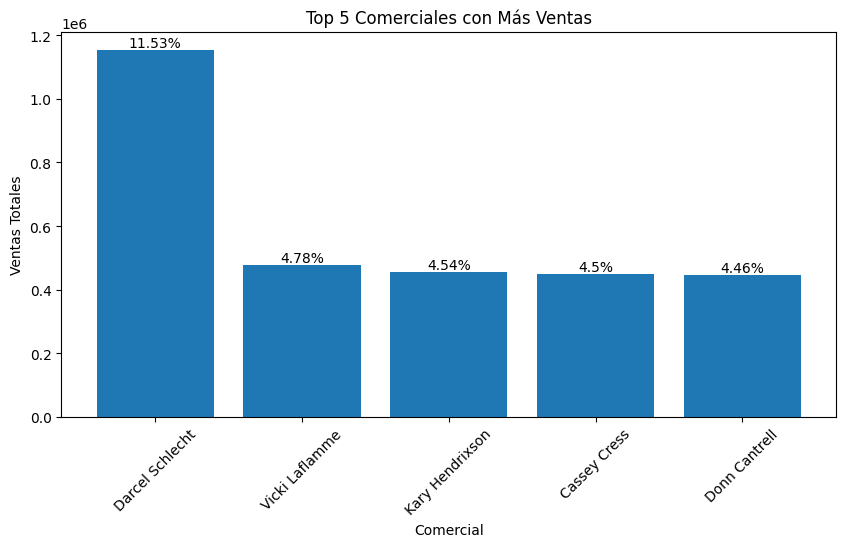

In [46]:
# =========================================
# GRAFICO TOP 5 COMERCIALES + %
# =========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.bar(
    top_sales_agents["sales_agent"],
    top_sales_agents["close_value"]
)

# agregar etiquetas %
for i, bar in enumerate(bars):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{top_sales_agents["%_del_total"][i]}%',
        ha='center',
        va='bottom'
    )

plt.title("Top 5 Comerciales con Más Ventas")
plt.xlabel("Comercial")
plt.ylabel("Ventas Totales")

plt.xticks(rotation=45)

plt.show()

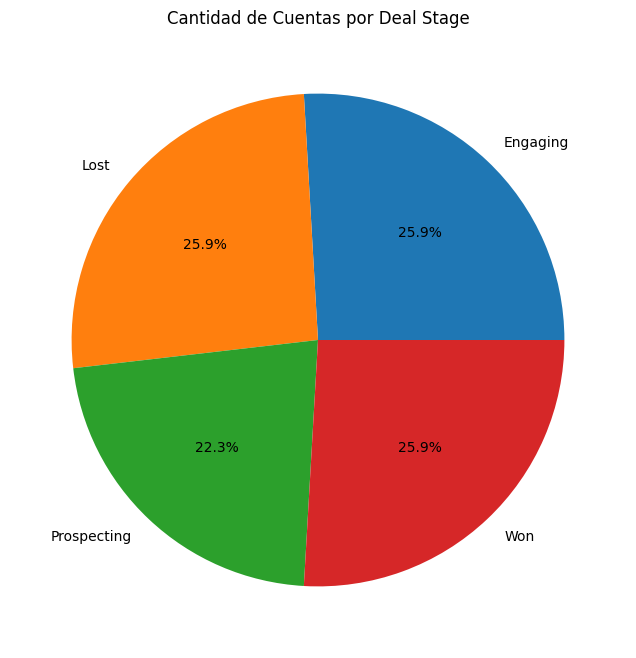

In [47]:
# =========================================
# PIE CHART:
# CANTIDAD DE CUENTAS POR DEAL STAGE
# =========================================

deal_stage_counts = (
    df.groupby("deal_stage")["account"]
    .nunique()
)

plt.figure(figsize=(8,8))

plt.pie(
    deal_stage_counts,
    labels=deal_stage_counts.index,
    autopct='%1.1f%%'
)

plt.title("Cantidad de Cuentas por Deal Stage")

plt.show()

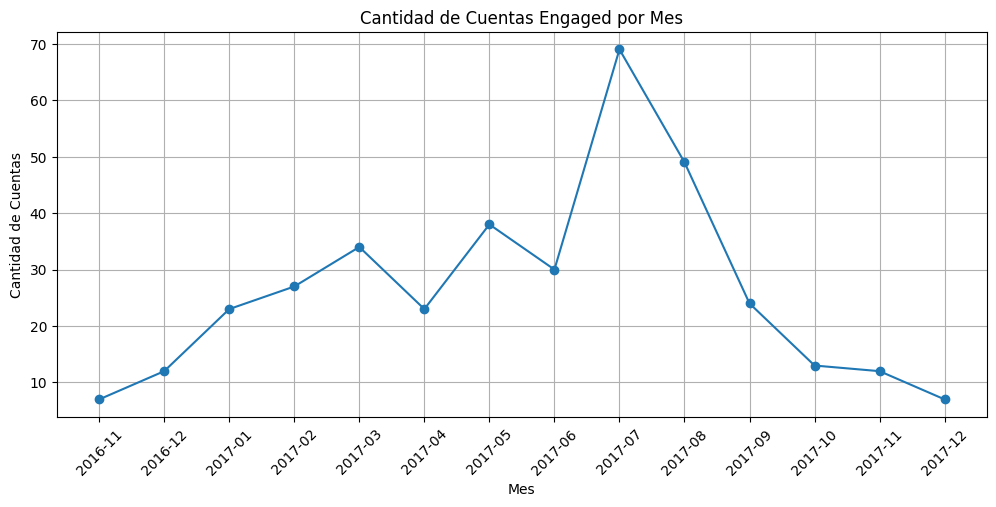

In [50]:
# =========================================
# GRAFICO DE LINEAS:
# CUENTAS ENGAGED POR MES
# =========================================

# filtrar solo deal_stage = Engaging
engaged_df = df[
    df["deal_stage"] == "Engaging"
].copy()

# extraer mes
engaged_df["engage_month"] = (
    engaged_df["engage_date"]
    .dt.to_period("M")
    .astype(str)
)

# contar cuentas por mes
monthly_engaged = (
    engaged_df.groupby("engage_month")["account"]
    .nunique()
)

# gráfico
plt.figure(figsize=(12,5))

plt.plot(
    monthly_engaged.index,
    monthly_engaged.values,
    marker="o"
)

plt.title("Cantidad de Cuentas Engaged por Mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de Cuentas")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

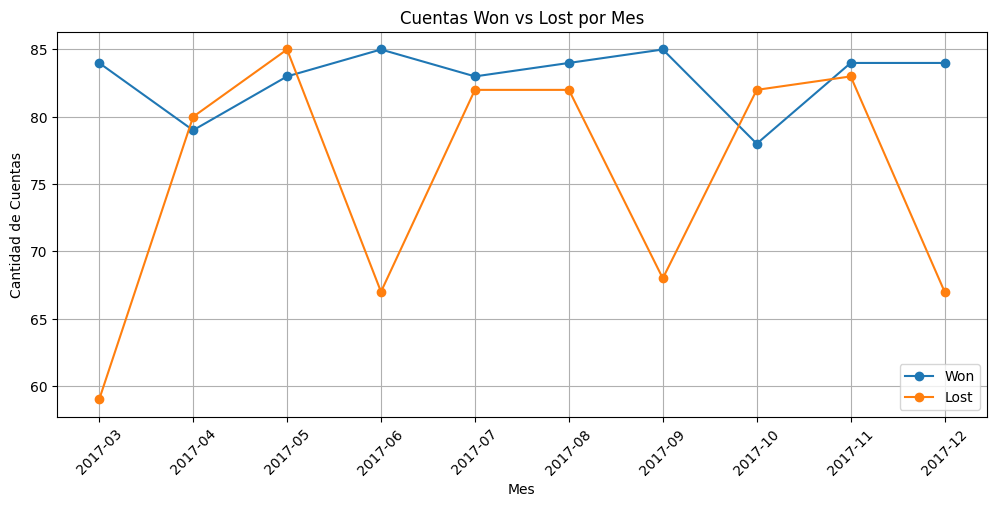

In [52]:
# =========================================
# GRAFICO:
# CUENTAS WON VS LOST POR MES
# =========================================

# WON
won_df = df[
    df["deal_stage"] == "Won"
].copy()

won_df["close_month"] = (
    won_df["close_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_won = (
    won_df.groupby("close_month")["account"]
    .nunique()
)

# LOST
lost_df = df[
    df["deal_stage"] == "Lost"
].copy()

lost_df["close_month"] = (
    lost_df["close_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_lost = (
    lost_df.groupby("close_month")["account"]
    .nunique()
)

# unir ambas series
comparison_df = pd.DataFrame({
    "Won": monthly_won,
    "Lost": monthly_lost
}).fillna(0)

# gráfico
plt.figure(figsize=(12,5))

plt.plot(
    comparison_df.index,
    comparison_df["Won"],
    marker="o",
    label="Won"
)

plt.plot(
    comparison_df.index,
    comparison_df["Lost"],
    marker="o",
    label="Lost"
)

plt.title("Cuentas Won vs Lost por Mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de Cuentas")

plt.xticks(rotation=45)

plt.legend()

plt.grid(True)

plt.show()

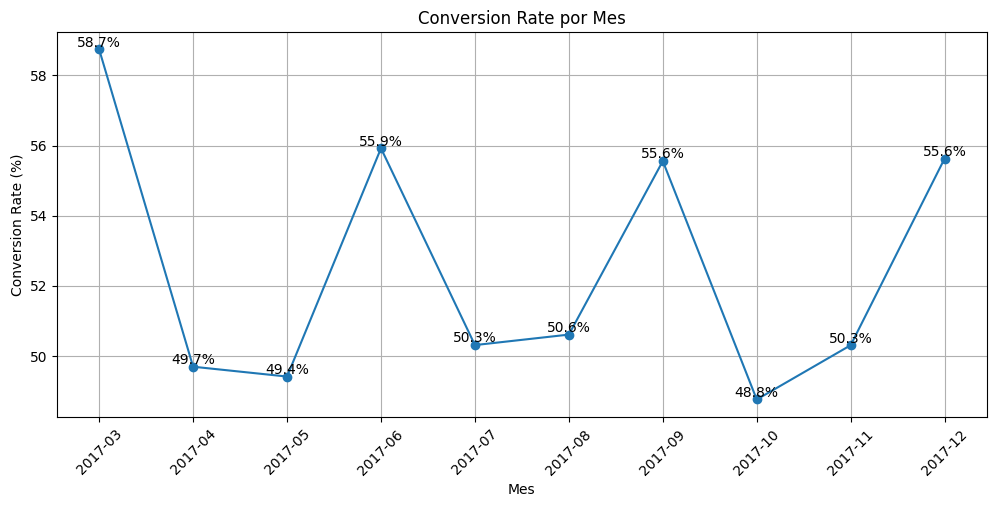

In [57]:
# =========================================
# CONVERSION RATE POR MES
# CONVERSION RATE = TOTAL WON / TOTAL WON + LOST
# =========================================

# WON
won_df = df[
    df["deal_stage"] == "Won"
].copy()

won_df["close_month"] = (
    won_df["close_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_won = (
    won_df.groupby("close_month")["account"]
    .nunique()
)

# LOST
lost_df = df[
    df["deal_stage"] == "Lost"
].copy()

lost_df["close_month"] = (
    lost_df["close_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_lost = (
    lost_df.groupby("close_month")["account"]
    .nunique()
)

# unir
conversion_df = pd.DataFrame({
    "Won": monthly_won,
    "Lost": monthly_lost
}).fillna(0)

# conversion rate
conversion_df["Conversion_Rate"] = (
    conversion_df["Won"] /
    (conversion_df["Won"] + conversion_df["Lost"])
) * 100

# gráfico
plt.figure(figsize=(12,5))

plt.plot(
    conversion_df.index,
    conversion_df["Conversion_Rate"],
    marker="o"
)

# agregar etiquetas %
for x, y in zip(
    conversion_df.index,
    conversion_df["Conversion_Rate"]
):

    plt.text(
        x,
        y,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Conversion Rate por Mes")
plt.xlabel("Mes")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

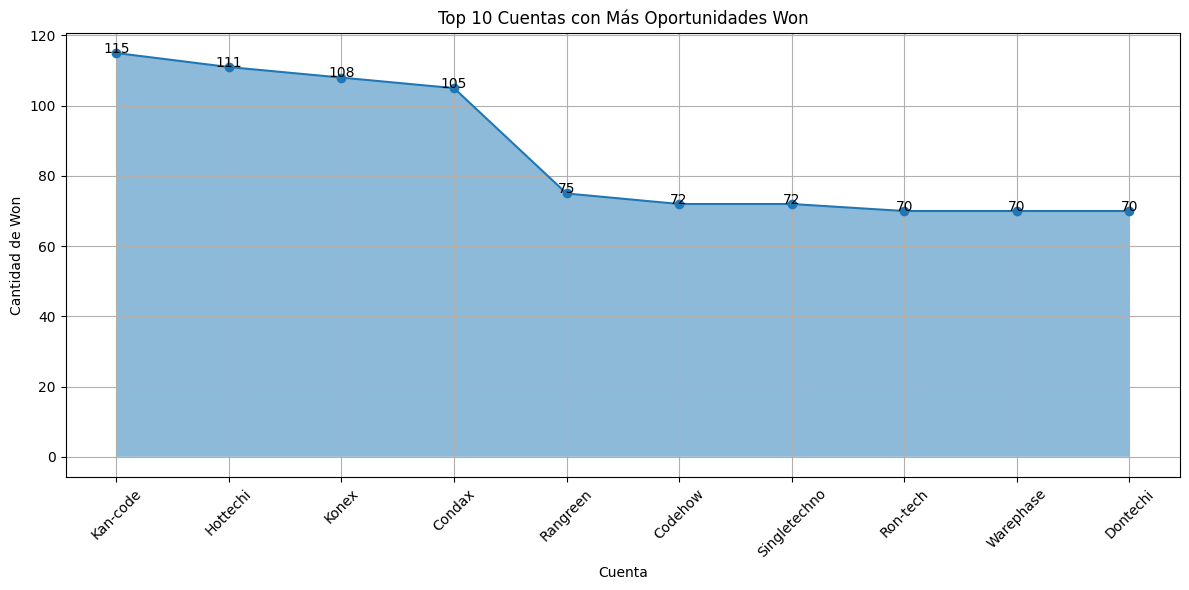

In [59]:
# =========================================
# TOP CUENTAS CON MÁS WON
# AREA CHART
# =========================================

top_accounts = (
    df[
        df["deal_stage"] == "Won"
    ]
    .groupby("account")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

# gráfico
plt.figure(figsize=(12,6))

plt.fill_between(
    top_accounts.index,
    top_accounts.values,
    alpha=0.5
)

plt.plot(
    top_accounts.index,
    top_accounts.values,
    marker="o"
)

# etiquetas
for x, y in zip(
    top_accounts.index,
    top_accounts.values
):

    plt.text(
        x,
        y + 0.1,
        str(y),
        ha="center"
    )

plt.title("Top 10 Cuentas con Más Oportunidades Won")
plt.xlabel("Cuenta")
plt.ylabel("Cantidad de Won")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

In [62]:
# =========================================
# TOP CUENTAS CON MAYOR CLOSED VALUE
# + % DEL TOTAL
# =========================================

# top cuentas
top_revenue_accounts = (
    df[
        df["deal_stage"] == "Won"
    ]
    .groupby("account")["close_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# revenue total
total_revenue = (
    df[
        df["deal_stage"] == "Won"
    ]["close_value"].sum()
)

# calcular %
top_revenue_accounts["%_del_total"] = (
    top_revenue_accounts["close_value"] /
    total_revenue * 100
).round(2)

display(top_revenue_accounts)

,account,close_value,%_del_total
0,Kan-code,341455.0,3.41
1,Konex,269245.0,2.69
2,Condax,206410.0,2.06
3,Cheers,198020.0,1.98
4,Hottechi,194957.0,1.95
5,Goodsilron,182522.0,1.82
6,Treequote,176751.0,1.77
7,Warephase,170046.0,1.70
8,Xx-holding,169357.0,1.69
9,Isdom,164683.0,1.65


In [73]:
# =========================================
# TOP CUENTAS CON MAYOR REVENUE
# + % DEL TOTAL
# =========================================

top_revenue_accounts = (
    df.groupby("account")["revenue"]
    .max()   # usar max porque revenue se repite por oportunidad
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# revenue total
total_revenue = (
    df["revenue"]
    .dropna()
    .unique()
    .sum()
)

# calcular %
top_revenue_accounts["%_del_total"] = (
    top_revenue_accounts["revenue"] /
    total_revenue * 100
).round(2)

display(top_revenue_accounts)

,account,revenue,%_del_total
0,Kan-code,11698.03,6.90
1,Hottechi,8170.38,4.82
2,Konex,7708.38,4.55
3,Xx-holding,7537.24,4.45
4,Initech,6395.05,3.77
5,Scotfind,6354.87,3.75
6,Treequote,5266.09,3.11
7,Ganjaflex,5158.71,3.04
8,Fasehatice,4968.91,2.93
9,Dontechi,4618.00,2.72


In [64]:
# =========================================
# TOTAL DE EMPLEADOS POR CUENTA
# =========================================

employees_per_account = (
    df[
        ["account", "employees"]
    ]
    .drop_duplicates()
    .sort_values(
        by="employees",
        ascending=False
    )
)

display(employees_per_account)

,account,employees
66,Kan-code,34288.0
32,Xx-holding,20293.0
123,Initech,20275.0
25,Ganjaflex,17479.0
16,Scotfind,16780.0
...,...,...
246,Zencorporation,142.0
116,Scottech,100.0
78,Dalttechnology,96.0
106,Condax,9.0


In [65]:
# =========================================
# TOP 5 CUENTAS CON MÁS EMPLEADOS
# =========================================

top_employees = (
    df.groupby("account")["employees"]
    .max()   # usar max porque el valor empleados se repite por oportunidad
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

display(top_employees)

,account,employees
0,Kan-code,34288.0
1,Xx-holding,20293.0
2,Initech,20275.0
3,Ganjaflex,17479.0
4,Scotfind,16780.0


In [70]:
# =========================================
# DURACIÓN PROMEDIO DEL CICLO WON VS LOST
# =========================================

# calcular duración
df["sales_cycle_days"] = (
    df["close_date"] - df["engage_date"]
).dt.days

# promedio por estado
avg_cycle = (
    df[
        df["deal_stage"].isin(
            ["Won", "Lost"]
        )
    ]
    .groupby("deal_stage")["sales_cycle_days"]
    .mean()
    .round(1)
)

# mostrar resultado
for stage, days in avg_cycle.items():

    print(f"{stage}: {days} days")

Lost: 41.5 days
Won: 51.8 days


In [71]:
# =========================================
# MAXIMO Y MINIMO SALES CYCLE & LA CUENTA CORRESPONDIENTE
# =========================================

# calcular duración
df["sales_cycle_days"] = (
    df["close_date"] - df["engage_date"]
).dt.days

# solo Won y Lost
cycle_df = df[
    df["deal_stage"].isin(
        ["Won", "Lost"]
    )
]

# promedio por cuenta
account_cycle = (
    cycle_df
    .groupby("account")["sales_cycle_days"]
    .mean()
    .reset_index()
)

# redondear
account_cycle["sales_cycle_days"] = (
    account_cycle["sales_cycle_days"]
    .round(1)
)

# máximo
max_cycle = account_cycle.loc[
    account_cycle["sales_cycle_days"].idxmax()
]

# mínimo
min_cycle = account_cycle.loc[
    account_cycle["sales_cycle_days"].idxmin()
]

# promedio general
avg_cycle = (
    account_cycle["sales_cycle_days"]
    .mean()
    .round(1)
)

# resultados
print("===== SALES CYCLE ANALYSIS =====\n")

print(
    f"MAXIMUM: {max_cycle['sales_cycle_days']} days "
    f"--> Account: {max_cycle['account']}"
)

print(
    f"MINIMUM: {min_cycle['sales_cycle_days']} days "
    f"--> Account: {min_cycle['account']}"
)

print(
    f"AVERAGE SALES CYCLE: {avg_cycle} days"
)

===== SALES CYCLE ANALYSIS =====

MAXIMUM: 67.0 days --> Account: Zoomit
MINIMUM: 36.6 days --> Account: Doncon
AVERAGE SALES CYCLE: 47.9 days


### **Conclusiones Clave del Análisis Exploratorio de los Datos**

## Conclusiones Clave del Análisis Exploratorio de los Datos

1. El análisis del pipeline comercial evidenció una distribución relativamente equilibrada entre oportunidades `Won`, `Lost` y `Engaging`, cada una representando aproximadamente el 25.9% del total de cuentas. Por otro lado, las oportunidades en estado `Prospecting` representaron el 22.3%, mostrando un pipeline comercial activo y balanceado entre oportunidades cerradas y oportunidades en proceso.

2. El producto con mayor desempeño comercial fue **GTXPro**, acumulando un valor total de cierre de **3,510,578 USD**, equivalente al **35.09%** del revenue total generado por oportunidades ganadas (`Won`). En segundo lugar se ubicó **GTX Plus Pro** con **2,629,651 USD** y una participación del **26.28%**, seguido por **MG Advanced** con **2,216,387 USD** y un **22.15%** del revenue total. Estos resultados evidencian una fuerte concentración del revenue en los productos premium del portafolio.

3. Los productos **GTX Plus Basic** y **GTX Basic** presentaron participaciones considerablemente menores, representando únicamente el **7.05%** y **4.99%** respectivamente, lo que sugiere una menor contribución de las líneas básicas al revenue comercial total.

4. En cuanto al desempeño del equipo comercial, el comercial con mayor revenue acumulado fue **Darcel Schlecht**, quien generó **1,153,214 USD**, representando el **11.53%** del revenue total. Posteriormente se destacaron:

   * **Vicki Laflamme** con **478,396 USD** (4.78%)
   * **Kary Hendrixson** con **454,298 USD** (4.54%)
   * **Cassey Cress** con **450,489 USD** (4.50%)
   * **Donn Cantrell** con **445,860 USD** (4.46%)

   Estos resultados muestran una importante diferencia entre el mejor comercial y el resto del equipo, evidenciando una alta concentración del revenue en determinados vendedores.

5. El análisis temporal de las cuentas en estado `Engaging` mostró un crecimiento progresivo desde finales de 2016 hasta alcanzar su punto máximo en **julio de 2017**, con aproximadamente **69 cuentas activas**, lo que indica un incremento importante en la actividad comercial y generación de oportunidades durante ese periodo. Posteriormente se observó una disminución gradual hacia finales de 2017.

6. El comportamiento mensual de oportunidades `Won` y `Lost` mostró una relativa estabilidad en las cuentas ganadas, manteniéndose generalmente entre **78 y 85 cuentas mensuales**. Sin embargo, las oportunidades perdidas presentaron mayor variabilidad, alcanzando su punto máximo en mayo de 2017 con aproximadamente **85 cuentas perdidas**.

7. El *Conversion Rate* mensual presentó fluctuaciones moderadas a lo largo del periodo analizado. El valor más alto se registró en **marzo de 2017**, alcanzando aproximadamente un **58.7%**, mientras que el valor más bajo se presentó en **octubre de 2017**, con un **48.8%**. En términos generales, el conversion rate se mantuvo cercano al 50%-56%, indicando una capacidad de conversión relativamente estable dentro del pipeline comercial.

La fórmula utilizada para el cálculo fue: Conversion Rate = Won / Won + Lost

